This is to compare the ellipse fits from SGA2025 to SGA2020 to see if they are any better

In [69]:
from astropy.table import Table, join, hstack

import numpy as np

from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib as mpl

from astropy.coordinates import SkyCoord, match_coordinates_sky
from astropy import units as u

import sys
sys.path.append('..')

from get_cutouts import get_cutout

In [47]:
# from recovering_galaxies.ipynb
tf_loa = Table.read('/pscratch/sd/d/dbustos/Fall_26/loa_before_VI.fits')
tf_loa[:5]

TARGETID,SGA_ID,TARGET_RA,TARGET_DEC,Z,Z_ERR,ZWARN,DELTACHI2,DIST,DIST_R26,PA,C_TO_F_ANGLE,ANGLE_OFF_AXIS,Selection,ZERR_MOD,unique_obs,Velocity,V_err,Z_center,deproj_dist,deproj_r26,unique_obs_vel
int64,int64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64
1084427169955849,556089,242.72318746350186,53.635782093163655,0.03063192091855999,0.03063192091855999,0,789.0584922824055,0.0017610627660455075,0.32999999905624167,44.0717658996582,224.0717662682332,0.0,1,0.030631930371296624,5.0,42.73534606638948,15854.996490748483,0.043112349961003466,0.0017610627660455075,0.32999999905624167,3.0
1084434300272644,375898,243.65642926326169,54.27724177905015,0.07850942434688926,0.07850942434688926,0,310.9083716990426,0.0018719092656299759,0.32999999823339154,54.93254852294922,54.93254783937784,0.0,1,0.07850942838567453,6.0,-186.32208858017614,52989.290517952046,0.15836028588343593,0.0018719092656299759,0.32999999823339154,3.0
1084427178344451,21266,243.62537013307835,53.712014537285526,0.05723634298805001,0.05723634298805001,0,849.3460895419121,0.0015670324751866896,0.32999999454262413,111.70044708251953,111.70044970679623,0.0,1,0.05723634831154621,5.0,190.61562929764193,38008.95273054255,0.11312930074849945,0.0015670324751866896,0.32999999454262413,3.0
1084434300272643,375898,243.65118121249577,54.275090804072406,0.07974131508417623,0.07974131508417623,0,1123.4490712519037,0.001871909265610506,0.3299999982299592,54.93254852294922,234.93254783934097,0.0,1,0.07974131906965695,6.0,155.89283818049722,53154.35944528527,0.15836028588343593,0.001871909265610506,0.3299999982299592,3.0
1084427178344450,21266,243.62044993111272,53.713173370492754,0.05591772316967483,0.05591772316967483,0,2463.962895900011,0.0015670324751904594,0.329999994543418,111.70044708251953,291.700449706759,0.0,1,0.05591772860512272,5.0,-183.53309221409478,37832.13467001295,0.11312930074849945,0.0015670324751904594,0.329999994543418,3.0


In [48]:
# these are the galaxies that I have marked as 'weird ellipse fit'
weird = [273359, 312817, 1038081, 1050664, 80392, 276280, 1032798, 193603, 1156840, 1333678, 16767, 80824, 75960, 572447, 1100149]

In [51]:
tf_loa = tf_loa[np.isin(tf_loa['SGA_ID'],weird)]

In [52]:
SGA = Table.read('/global/cfs/cdirs/cosmo/www/sga/2025/SGA2025-v1.0.fits')
SGA[:5]

SGAID,SGANAME,GALAXY,ALTNAMES,OBJNAME,PGC,RA,DEC,RA_TRACTOR,DEC_TRACTOR,MORPH,SGAGROUP,REGION,SAMPLE,ELLIPSEBIT,ELLIPSEMODE,BANDS,Z,Z_IVAR,Z_REF,Z_FLAG,DIST,DIST_IVAR,DIST_REF,DIST_METHOD,Z_PHOT,Z_PHOT_IVAR,Z_COSMO,Z_COSMO_IVAR,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,D26,D26_ERR,D26_REF,BA,PA,SMA_MOMENT,BA_MOMENT,PA_MOMENT,SMA50_G,SMA50_R,SMA50_I,SMA50_Z,SMA50_ERR_G,SMA50_ERR_R,SMA50_ERR_I,SMA50_ERR_Z,SMA_FLUX,FLUX_G,FLUX_R,FLUX_I,FLUX_Z,FLUX_W1,FLUX_W2,FLUX_W3,FLUX_W4,FLUX_FUV,FLUX_NUV,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_I,FLUX_IVAR_Z,FLUX_IVAR_W1,FLUX_IVAR_W2,FLUX_IVAR_W3,FLUX_IVAR_W4,FLUX_IVAR_FUV,FLUX_IVAR_NUV,FLUX_REF,EBV,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_I,MW_TRANSMISSION_Z,MW_TRANSMISSION_W1,MW_TRANSMISSION_W2,MW_TRANSMISSION_W3,MW_TRANSMISSION_W4,MW_TRANSMISSION_FUV,MW_TRANSMISSION_NUV,PSFSIZE_G,PSFSIZE_R,PSFSIZE_I,PSFSIZE_Z,PSFDEPTH_G,PSFDEPTH_R,PSFDEPTH_I,PSFDEPTH_Z,TARGETID_DESI,SURVEY_DESI,PROGRAM_DESI,Z_DESI,Z_IVAR_DESI,ZWARN_DESI,DELTACHI2_DESI,SPECTYPE_DESI,NSPEC_DESI,SPECOBJID_SDSS,Z_SDSS,Z_IVAR_SDSS,CLASS_SDSS,Z_NED,Z_IVAR_NED,Z_REF_NED,DIST_NED,DIST_IVAR_NED,DIST_NED_MEAN_METHOD,DIST_NED_DIRECT,DIST_IVAR_NED_DIRECT,DIST_NED_DIRECT_METHOD,NED_FLAG,NED_Z_FLAG,Z_LVD,Z_IVAR_LVD,DIST_LVD,DIST_IVAR_LVD,RA_INIT,DEC_INIT,DIAM_INIT,BA_INIT,PA_INIT,MAG_INIT,OPTFLUX,SMA_MASK,INIT_REF
,,,,,,deg,deg,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,nanomaggies,nanomaggies,nanomaggies,nanomaggies,nanomaggies,nanomaggies,nanomaggies,nanomaggies,nanomaggies,nanomaggies,nanomaggies^(-2),nanomaggies^(-2),nanomaggies^(-2),nanomaggies^(-2),nanomaggies^(-2),nanomaggies^(-2),nanomaggies^(-2),nanomaggies^(-2),nanomaggies^(-2),nanomaggies^(-2),nanomaggies,mag,,,,,,,,,,,arcsec,arcsec,arcsec,arcsec,nanomaggies^(-2),nanomaggies^(-2),nanomaggies^(-2),nanomaggies^(-2),,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
int64,bytes25,bytes35,bytes200,bytes30,int32,float64,float64,float64,float64,bytes36,bytes18,int16,int32,int32,int32,bytes4,float64,float64,bytes4,int16,float32,float32,bytes10,bytes16,float64,float64,float64,float64,bytes10,int16,bool,float64,float64,float32,float32,float32,bytes3,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,bytes8,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int64,bytes7,bytes6,float64,float64,int64,float64,bytes6,int32,bytes22,float64,float64,bytes6,float64,float64,bytes19,float32,float32,bytes17,float32,float32,bytes12,int32,int32,float64,float64,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,bytes14
1,SGA2025 J0000.066-072.186,ESO 050-IG 005 NED01,WISEA J000015.87-721110.1|ESO-LV 0500050|MRSS 028-317113,ESO 050-IG 005 NED01,19,0.06620700222837696,-72.18653561329143,0.06620700223338022,-72.18653561311244,--,SGA2025_00006m7218,1,0,0,0,griz,0.0,0.0,--,0,350.71973,9.4408926e-05,ZCOSMO,HUBBLE_FLOW,0.07760173827409744,2152.9923001223474,0.07737747407225894,2152.9923001223474,00006m7218,1,True,0.06620797145114272,-72.18653503138897,0.6036194,0.5925561,0.006441001,r26,0.64823765,166.15268,11.663855,0.64823765,166.15268,3.8450856,3.487869,3.4087875,3.2336173,0.06435573,0.045308433,0.042498562,0.042933732,23.32771,203.6904,471.61075,678.33307,887.4653,828.66266,529.3157,947.82336,1156.6313,-0.5876496,3.6441207,10.949669,6.961739,6.7416224,0.44981217,0.4119082,0.1619783,0.00066200114,2.5489986e-05,0.63958246,1.2855954,AP04,0.032997746,0.90699416,0.9363477,0.9527967,0.96386427,0.99442345,0.9965716,0.9992678,0.9997235,0.81346434,0.81775266,1.3493062,1.3249475,1.3020111,1.0920181,26.96713,26.675224,26.639301,25.43927,-1,--,--,0.0,0.0,-1,-1.0,--,0,--,0.0,0.0,--,0.0,0.0,--,0.0,0.0,--,0.0,0.0,--,0,0,0.0,0.0,0.0,0.0,0.0663333333333333

In [66]:
SGA_dict = {}
for i in range(len(SGA)):
    SGA_dict[SGA['SGAID'][i]] = i

In [53]:
# do a coordinate crossmatch to find the 2025 SGA ID corresponding to the galaxy
loa_coords = SkyCoord(ra = tf_loa['TARGET_RA']*u.deg, dec = tf_loa['TARGET_DEC']*u.deg)
SGA_coords = SkyCoord(ra = SGA['RA'], dec = SGA['DEC'])

In [54]:
#index, 2d separation, 3d separation
idx, d2d, d3d = match_coordinates_sky(SGA_coords, loa_coords)

In [55]:
#get only the targets within 1 arcsec
max_sep = 1 * u.arcsec
sep_constraint = d2d < max_sep

sga_matches = SGA[sep_constraint]
loa_match = tf_loa[idx[sep_constraint]]

In [56]:
loa_2025 = hstack([sga_matches['SGAID'],loa_match])
loa_2025

SGAID,TARGETID,SGA_ID,TARGET_RA,TARGET_DEC,Z,Z_ERR,ZWARN,DELTACHI2,DIST,DIST_R26,PA,C_TO_F_ANGLE,ANGLE_OFF_AXIS,Selection,ZERR_MOD,unique_obs,Velocity,V_err,Z_center,deproj_dist,deproj_r26,unique_obs_vel
int64,int64,int64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64
4695873,39627965264300842,80392,342.76257837159835,7.2957932625051045,0.010704899409451935,0.010704899409451935,0,3555.7556070303544,0.0,0.0,67.73889923095703,0.0,0.0,1,0.010704925422443614,6.0,0.0,4538.57322611986,0.010704925422443614,0.0,0.0,6.0
4695978,2842563753017344,80824,226.7820299104975,1.5442757379659497,0.00849645928292198,0.00849645928292198,0,275593.487542253,0.0,0.0,116.56114196777344,0.0,0.0,1,0.008496491914240284,33.0,0.0,3602.262434922438,0.008496491914240284,0.0,0.0,27.0
4747041,39628046713489705,273359,214.70206786987538,10.843797150557341,0.05593770704974079,0.05593770704974079,0,13463.951194602996,0.0,0.0,128.75955200195312,0.0,0.0,1,0.05593771248345252,3.0,0.0,23715.94328677123,0.05593771248345252,0.0,0.0,3.0
4747771,2851314346229760,276280,34.9214252577226,-0.2556915478602802,0.025689129498196007,0.025689129498196007,0,444131.252076149,0.0,0.0,3.7345352172851562,0.0,0.0,1,0.02568914066185859,5.0,0.0,10891.439352346646,0.02568914066185859,0.0,0.0,5.0
4757651,39628300837983546,312817,154.44935347080175,21.87347588998076,0.0052837962288286916,0.0052837962288286916,0,6923.508813393506,0.0,0.0,108.22411346435547,0.0,0.0,1,0.005283848366765339,4.0,0.0,2240.196151016636,0.005283848366765339,0.0,0.0,3.0
4947626,39628182567002113,1032798,261.77470130656957,16.454141633275167,0.08253224077289971,0.08253224077289971,0,702.4240528524388,0.0,0.0,75.28326416015625,0.0,0.0,1,0.08253224464353909,3.0,0.0,34991.24197964153,0.08253224464353909,0.0,0.0,3.0
4948985,39628163344502170,1038081,150.358060644638,15.770098219865044,0.007918585656729107,0.007918585656729107,0,53978.5144370012,0.0,0.0,29.686180114746094,0.0,0.0,1,0.00791862062925558,3.0,0.0,3357.2620226191098,0.00791862062925558,0.0,0.0,3.0
4952173,2851457845952512,1050664,315.8942741434099,5.521884907887999,0.0602075976516799,0.0602075976516799,0,23875.174366235733,0.0,0.0,60.28056716918945,0.0,0.0,1,0.06020760274094631,4.0,0.0,25526.25105038269,0.06020760274094631,0.0,0.0,4.0
4679172,39633361764876523,16767,147.12868583722562,57.97075824528501,0.02801518905511883,0.02801518905511883,0,54126.26184171904,0.0,0.0,101.25171661376953,0.0,0.0,1,0.02801519933836196,5.0,0.0,11877.619752018421,0.02801519933836196,0.0,0.0,4.0


In [37]:
xmatch_dict = {}
for i in range(len(loa_2025)):
    xmatch_dict[loa_2025['SGA_ID'][i]] = i

In [59]:
tf_loa['SGA2025'] = np.nan

In [61]:
for i in np.unique(tf_loa['SGA_ID']):

    if i not in xmatch_dict:
        continue
    
    idx = xmatch_dict[i]

    sga_2025_id = loa_2025['SGAID'][idx]

    fiber = tf_loa['SGA_ID'] == i

    obs = tf_loa[fiber]

    tf_loa['SGA2025'][fiber] = sga_2025_id

In [64]:
loa_new = tf_loa[np.isfinite(tf_loa['SGA2025'])]
loa_new

TARGETID,SGA_ID,TARGET_RA,TARGET_DEC,Z,Z_ERR,ZWARN,DELTACHI2,DIST,DIST_R26,PA,C_TO_F_ANGLE,ANGLE_OFF_AXIS,Selection,ZERR_MOD,unique_obs,Velocity,V_err,Z_center,deproj_dist,deproj_r26,unique_obs_vel,SGA2025
int64,int64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64
39627779272087289,276280,34.920162354693446,-0.2525838610657032,0.025947569449105524,0.025947569449105524,0,3453.658217191696,0.003354491003938307,0.2969974405062721,3.7345352172851562,337.88433232611936,334.1497971088342,1,0.025947580507147565,5.0,75.53784660515701,10946.361893994592,0.02568914066185859,0.005753081232755285,0.5093620460293273,5.0,4747771.0
39627779272087190,276280,34.91770288313582,-0.2638877538685383,0.0255213680029695,0.0255213680029695,0,5034.175372838974,0.009001865396006467,0.7970004925507528,3.7345352172851562,204.425335640611,200.69080042332584,1,0.02552137923633942,5.0,-49.033990480427306,10855.934650073628,0.02568914066185859,0.01029917072282201,0.9118603509218188,5.0,4747771.0
39627779272087337,276280,34.92153701325342,-0.25979208490748956,0.025586629621786268,0.025586629621786268,0,48595.89215683937,0.004102059619443282,0.3631851170113298,3.7345352172851562,178.43887038185954,174.7043351645744,1,0.02558664082793034,5.0,-29.959067528177638,10869.732613825408,0.02568914066185859,0.00719813229428377,0.6373029068546988,5.0,4747771.0
39627779272087416,276280,34.92371282911623,-0.2533063452624702,0.02608185370155651,0.02608185370155651,0,25896.14608490467,0.003304855680179357,0.29260286496625687,3.7345352172851562,43.802780137350574,40.06824492006542,1,0.026081864705545486,5.0,114.78697673159046,10975.006829242133,0.02568914066185859,0.004839394262037559,0.4284667056010766,5.0,4747771.0
39627965264300947,80392,342.76745165374217,7.281914611074319,0.010683856953467965,0.010683856953467965,0,1366.0666671115905,0.014696379569878685,0.9019132378394351,67.73889923095703,160.79658312365336,93.05768389269633,1,0.010683883016608286,6.0,-6.241554389879177,4534.114740045102,0.010704925422443614,0.01692944772585729,1.0389560871546986,6.0,4695873.0
39627965264300822,80392,342.7617457974708,7.293038683098317,0.010641409039967978,0.010641409039967978,0,33865.21863526106,0.002875710822623496,0.17648167338016518,67.73889923095703,196.68903259035713,128.9501333594001,1,0.01064143520487433,6.0,-18.832335667909504,4525.1342499833045,0.010704925422443614,0.0028870508464478974,0.17717760788267387,6.0,4695873.0
39627965264300754,80392,342.7592261794114,7.305684766121375,0.01068943051025296,0.01068943051025296,0,15960.663820788264,0.010435399874954966,0.6404179508713902,67.73889923095703,341.42021323884165,273.6813140078846,1,0.010689456560091088,6.0,-4.588341578347096,4535.2952404784755,0.010704925422443614,0.01068173165300908,0.655535272145732,6.0,4695873.0
39627965264301014,80392,342.7702449080025,7.282469428628679,0.010721084519049174,0.010721084519049174,0,19351.823423445225,0.015341257391448685,0.9414892328181659,67.73889923095703,150.2839455372844,82.54504630632738,1,0.010721110493602252,6.0,4.800781901794197,4542.005518836053,0.010704925422443614,0.0169396825313331,1.039584194676109,6.0,4695873.0
39627965264300842,80392,342.76257837159835,7.2957932625051045,0.010704899409451935,0.010704899409451935,0,3555.7556070303544,0.0,0.0,67.73889923095703,0.0,0.0,1,0.010704925422443614,6.0,0.0,4538.57322611986,0.010704925422443614,0.0,0.0,6.0,4695873.0


  0%|          | 0/10 [00:00<?, ?it/s]

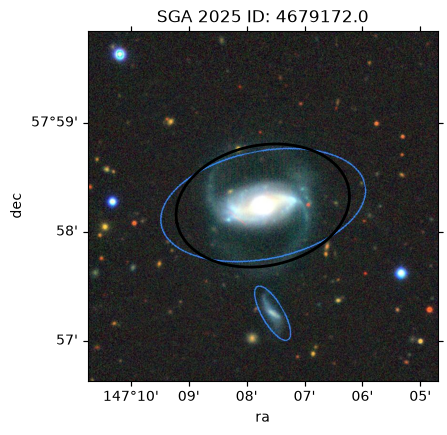

 10%|█         | 1/10 [00:01<00:10,  1.15s/it]

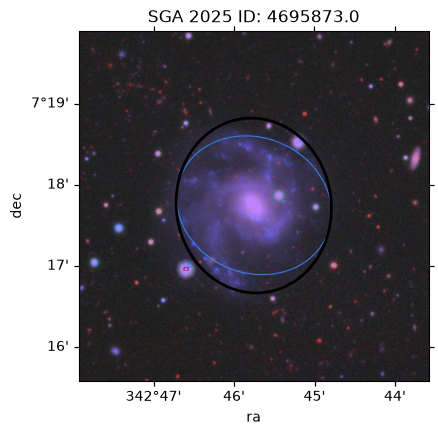

 20%|██        | 2/10 [00:02<00:12,  1.55s/it]

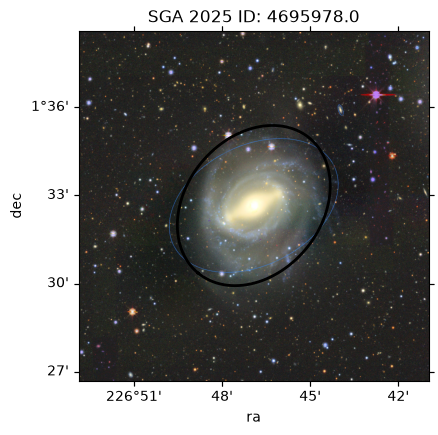

 30%|███       | 3/10 [00:17<00:51,  7.31s/it]

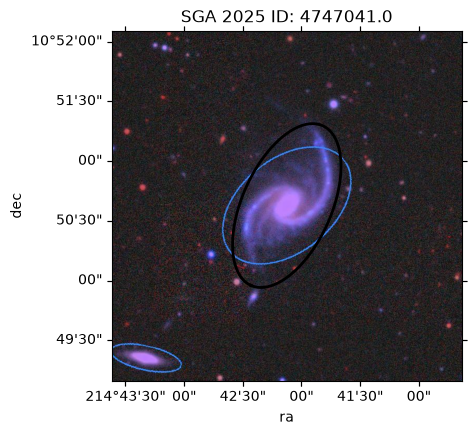

 40%|████      | 4/10 [00:18<00:30,  5.04s/it]

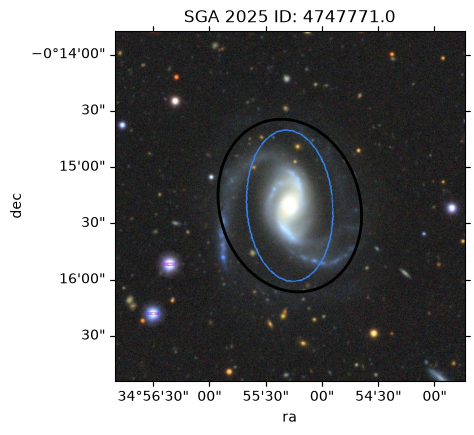

 50%|█████     | 5/10 [00:20<00:18,  3.79s/it]

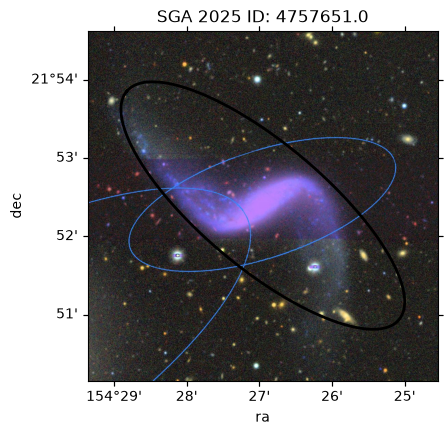

 60%|██████    | 6/10 [00:23<00:14,  3.55s/it]

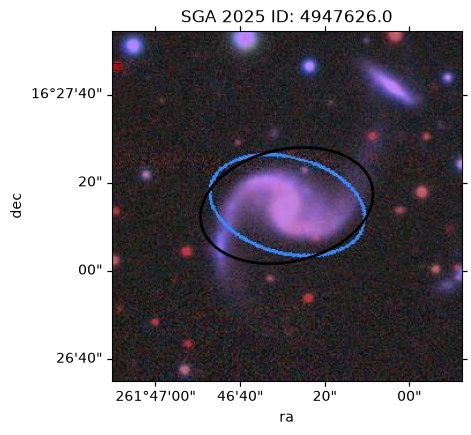

 70%|███████   | 7/10 [00:24<00:07,  2.65s/it]

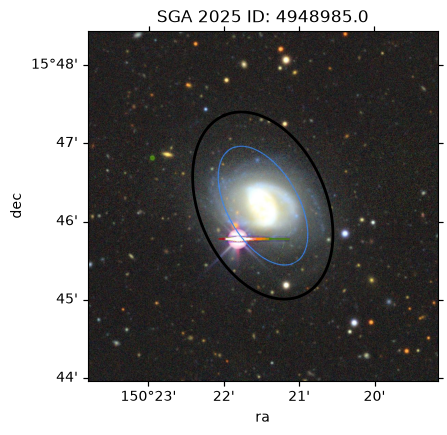

 80%|████████  | 8/10 [00:26<00:04,  2.45s/it]

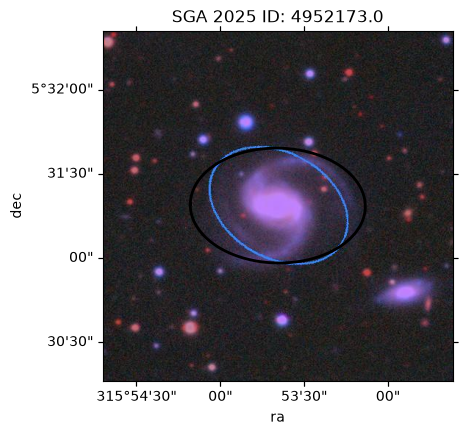

 90%|█████████ | 9/10 [00:27<00:02,  2.00s/it]

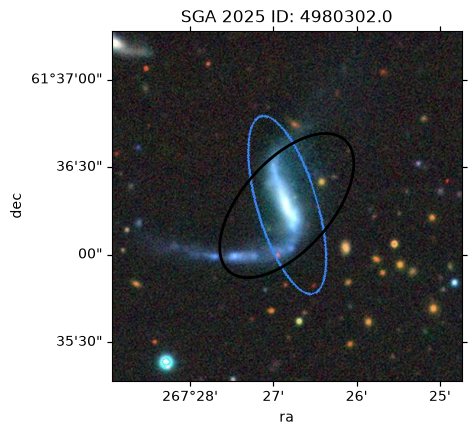

100%|██████████| 10/10 [00:28<00:00,  2.81s/it]


In [82]:
for sga_id in tqdm(np.unique(loa_new['SGA2025'])):
    
    #identify all targets in the galaxy
    targ_list = loa_new[loa_new['SGA2025']==sga_id]

    #find the index for this target in SGA
    sga_idx = SGA_dict[sga_id]
    
    #get coordinates for center of galaxy
    center_ra, center_dec = float(SGA['RA'][sga_idx]), float(SGA['DEC'][sga_idx])


    # #get velocities for each point
    # velocity = np.array(targ_list['Velocity'])

    # #find max velocity for colormap
    # v_max = max((v for v in abs(velocity) if v<=1000), default=1000)

#-------------------------------------------
# get cutout
#-------------------------------------------
    # D26 in arcmin
    d26 = SGA['D26'][sga_idx]
    
    pix = int(2 * d26*60/0.262)

    if (pix < 2500):
        npix = np.minimum(pix,1024)

    elif (pix > 2500):
        npix = np.minimum(pix,3000)

    sga_2020_id = targ_list['SGA_ID'][0]
    img_file, wcs = get_cutout(sga_2020_id, center_ra, center_dec, dir='/pscratch/sd/d/dbustos/Fall_26/weird_ellipse/',dr=10,size=npix)
    img = mpl.image.imread(img_file)

    fig1 = plt.figure(figsize=(7,5))


    ax = fig1.add_subplot(111, projection=wcs)
    
    #add the cutout to make ellipse right size, but set opacity to 0
    ax.imshow(np.flip(img, axis=0))
    ax.coords[0].set_format_unit(u.deg)
    ax.set(xlabel='ra', ylabel='dec')
#---------------------------------
# generate ellipse
#---------------------------------
    
    #PA for ellipse in rad
    PA = np.radians(SGA['PA'][sga_idx])
    
    #radius semimajor axis in arcmin
    smajor = (d26/2)/60
    #radius semiminor axis in arcmin
    sminor = ((SGA['BA'][sga_idx]) * smajor)

    theta = np.linspace(0,2*np.pi,365)
    # ellipse coordinates before transformation
    smajor1 = smajor * np.cos(theta)
    sminor1 = sminor * np.sin(theta)

    # rotation matrix
    rot_ra = (smajor1*np.sin(PA) + sminor1*np.cos(PA))/np.cos(np.radians(center_dec))
    rot_dec = smajor1*np.cos(PA) - sminor1*np.sin(PA)
 
    #ellipse coordinates after transformation
    ellipse_ra = center_ra + rot_ra
    ellipse_dec = center_dec + rot_dec

    ax.plot(ellipse_ra,ellipse_dec,color = 'black',lw=2,transform= ax.get_transform('icrs'))


    ax.set_title('SGA 2025 ID: {}'.format(sga_id))
    fig1.subplots_adjust(top=0.85, right=0.85, bottom=0.15, left=0.15)

    plt.show()
    
    # fig1.savefig('/pscratch/sd/d/dbustos/vel_maps/' + 'sga_{}_velocity_map.png'.format(sga_id), dpi=120)
    
    fig1.clear()
    # plt.close(fig1)

In [ ]:
weird = [ 193603, 1333678, 75960, 572447, 1100149]